In [33]:
# ── FULL DIAGNOSTIC — run this before anything else ────────────────────
import pandas as pd
from sqlalchemy import create_engine, inspect, text

engine = create_engine("postgresql://postgres@localhost:5432/financial_health")
inspector = inspect(engine)

# 1. Column names in every relevant table
for table in ['dim_company', 'dim_year', 
              'fact_profit_loss', 'fact_balance_sheet', 'fact_cash_flow']:
    cols = [c['name'] for c in inspector.get_columns(table)]
    print(f"\n── {table} ──")
    print(cols)

# 2. Sample rows from dim_company (check if real names are stored)
print("\n── dim_company sample ──")
print(pd.read_sql("SELECT * FROM dim_company LIMIT 5", engine))

# 3. Sample rows from fact_profit_loss (check actual column names + values)
print("\n── fact_profit_loss sample ──")
print(pd.read_sql("SELECT * FROM fact_profit_loss LIMIT 3", engine))

# 4. Sample from fact_balance_sheet
print("\n── fact_balance_sheet sample ──")
print(pd.read_sql("SELECT * FROM fact_balance_sheet LIMIT 3", engine))

# 5. Sample from fact_cash_flow
print("\n── fact_cash_flow sample ──")
print(pd.read_sql("SELECT * FROM fact_cash_flow LIMIT 3", engine))


── dim_company ──
['company_id', 'company_name', 'sector', 'roe_percentage']

── dim_year ──
['year_id', 'year_label', 'year_date']

── fact_profit_loss ──
['id', 'company_id', 'year_id', 'sales', 'net_profit', 'opm_pct', 'operating_profit', 'interest', 'expenses', 'dividend_payout_pct']

── fact_balance_sheet ──
['id', 'company_id', 'year_id', 'debt_to_equity', 'borrowings', 'equity_capital', 'reserves', 'total_assets']

── fact_cash_flow ──
['id', 'company_id', 'year_id', 'operating_activity', 'investing_activity', 'free_cash_flow']

── dim_company sample ──
   company_id company_name   sector  roe_percentage
0           1          TCS  Unknown           51.80
1           2     RELIANCE  Unknown            9.25
2           3     HDFCBANK  Unknown           13.80
3           4         INFY  Unknown           31.90
4           5    ICICIBANK  Unknown           16.10

── fact_profit_loss sample ──
     id  company_id  year_id sales net_profit  opm_pct  operating_profit  \
0  1947      

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sqlalchemy import create_engine
from dotenv import load_dotenv
import warnings, os

warnings.filterwarnings('ignore')
load_dotenv('../.env')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST','localhost')}:{os.getenv('DB_PORT','5432')}"
    f"/{os.getenv('DB_NAME')}"
)

comp = pd.read_sql("SELECT * FROM dim_company", engine)
pl   = pd.read_sql("SELECT * FROM fact_profit_loss", engine)
bs   = pd.read_sql("SELECT * FROM fact_balance_sheet", engine)
cf   = pd.read_sql("SELECT * FROM fact_cash_flow", engine)
yr   = pd.read_sql("SELECT * FROM dim_year", engine)
ana  = pd.read_sql("SELECT * FROM fact_analysis", engine)

for col in ['sales','net_profit','opm_pct','operating_profit','interest','expenses','dividend_payout_pct']:
    pl[col] = pd.to_numeric(pl[col], errors='coerce')
for col in ['debt_to_equity','borrowings','equity_capital','reserves','total_assets']:
    bs[col] = pd.to_numeric(bs[col], errors='coerce')
for col in ['operating_activity','investing_activity','free_cash_flow']:
    cf[col] = pd.to_numeric(cf[col], errors='coerce')
comp['roe_percentage'] = pd.to_numeric(comp['roe_percentage'], errors='coerce')

print(f"✅ {comp.shape[0]} companies loaded")

✅ 94 companies loaded


In [35]:
# Step 1 — Build feature matrix
avg_opm = pl.groupby('company_id')['opm_pct'].mean().reset_index().rename(columns={'opm_pct': 'avg_opm'})
avg_dividend = pl.groupby('company_id')['dividend_payout_pct'].mean().reset_index().rename(columns={'dividend_payout_pct': 'avg_dividend'})
avg_de = bs.groupby('company_id')['debt_to_equity'].mean().reset_index().rename(columns={'debt_to_equity': 'avg_de'})

cf_pl = cf.merge(pl[['company_id', 'year_id', 'net_profit']], on=['company_id', 'year_id'], how='left')
cf_pl['ccr'] = cf_pl['operating_activity'] / cf_pl['net_profit'].replace(0, np.nan)
avg_ccr = cf_pl.groupby('company_id')['ccr'].mean().reset_index().rename(columns={'ccr': 'avg_ccr'})

cagr3 = ana[(ana['metric'] == 'compounded_sales_growth') & (ana['period_label'] == '3Y')]
cagr3 = cagr3[['company_id', 'value_pct']].rename(columns={'value_pct': 'avg_growth_3y'})

features = comp[['company_id', 'company_name', 'sector', 'roe_percentage']].copy()
features = features.merge(avg_opm, on='company_id', how='left')
features = features.merge(avg_dividend, on='company_id', how='left')
features = features.merge(avg_de, on='company_id', how='left')
features = features.merge(avg_ccr, on='company_id', how='left')
features = features.merge(cagr3, on='company_id', how='left')
features = features.fillna(features.median(numeric_only=True))

feature_cols = ['avg_opm', 'roe_percentage', 'avg_growth_3y', 'avg_de', 'avg_ccr', 'avg_dividend']

scaler = StandardScaler()
features[feature_cols] = features[feature_cols].fillna(0)
X_scaled = scaler.fit_transform(features[feature_cols])

print(f"✅ Feature matrix ready: {features.shape}")

✅ Feature matrix ready: (94, 9)


In [36]:
# Step 2 — Cosine similarity between all company pairs
# Step 2 — Cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

# NaN fix
features[feature_cols] = features[feature_cols].fillna(0)
X_scaled = scaler.fit_transform(features[feature_cols])

sim_matrix = cosine_similarity(X_scaled)
sim_df = pd.DataFrame(
    sim_matrix,
    index=features['company_name'].values,
    columns=features['company_name'].values
)

print(f"✅ Similarity matrix: {sim_df.shape}")
first = features['company_name'].iloc[0]
print(f"\nTop similarities for {first}:")
print(sim_df[first].sort_values(ascending=False).head(6))

✅ Similarity matrix: (94, 94)

Top similarities for TCS:
TCS           1.000000
NESTLEIND     0.987393
BRITANNIA     0.949679
MARICO        0.929881
PIDILITIND    0.929451
INFY          0.913192
Name: TCS, dtype: float64


In [37]:
# Step 3 — Find top 5 peers for each company
def get_top_peers(company_name, n=5):
    if company_name not in sim_df.columns:
        return []
    
    # .squeeze() ensures Series mil sake, DataFrame nahi
    scores = sim_df[company_name].squeeze().drop(company_name, errors='ignore')
    
    # Agar abhi bhi DataFrame hai toh pehla column lo
    if isinstance(scores, pd.DataFrame):
        scores = scores.iloc[:, 0]
    
    top = scores.nlargest(n)
    result = []
    for peer, score in top.items():
        sector = features[features['company_name'] == peer]['sector'].values
        sector = sector[0] if len(sector) > 0 else 'Unknown'
        result.append({
            'peer_name': peer,
            'similarity': round(float(score), 4),
            'sector': sector
        })
    return result

peer_mapping = []
for company in features['company_name']:
    peers = get_top_peers(company, n=5)
    company_sector = features[features['company_name'] == company]['sector'].values
    company_sector = company_sector[0] if len(company_sector) > 0 else 'Unknown'
    for rank, peer in enumerate(peers, 1):
        peer_mapping.append({
            'company_name': company,
            'company_sector': company_sector,
            'peer_rank': rank,
            'peer_name': peer['peer_name'],
            'peer_sector': peer['sector'],
            'similarity_score': peer['similarity']
        })

peer_df = pd.DataFrame(peer_mapping)
print(f"✅ Peer mapping done — {len(peer_df)} records")

# Show sample — first real company
first_company = features['company_name'].iloc[0]
display(peer_df[peer_df['company_name'] == first_company])

✅ Peer mapping done — 470 records


,company_name,company_sector,peer_rank,peer_name,peer_sector,similarity_score
0,TCS,Unknown,1,NESTLEIND,Unknown,0.9874
1,TCS,Unknown,2,BRITANNIA,Unknown,0.9497
2,TCS,Unknown,3,MARICO,Unknown,0.9299
3,TCS,Unknown,4,PIDILITIND,Unknown,0.9295
4,TCS,Unknown,5,INFY,Unknown,0.9132


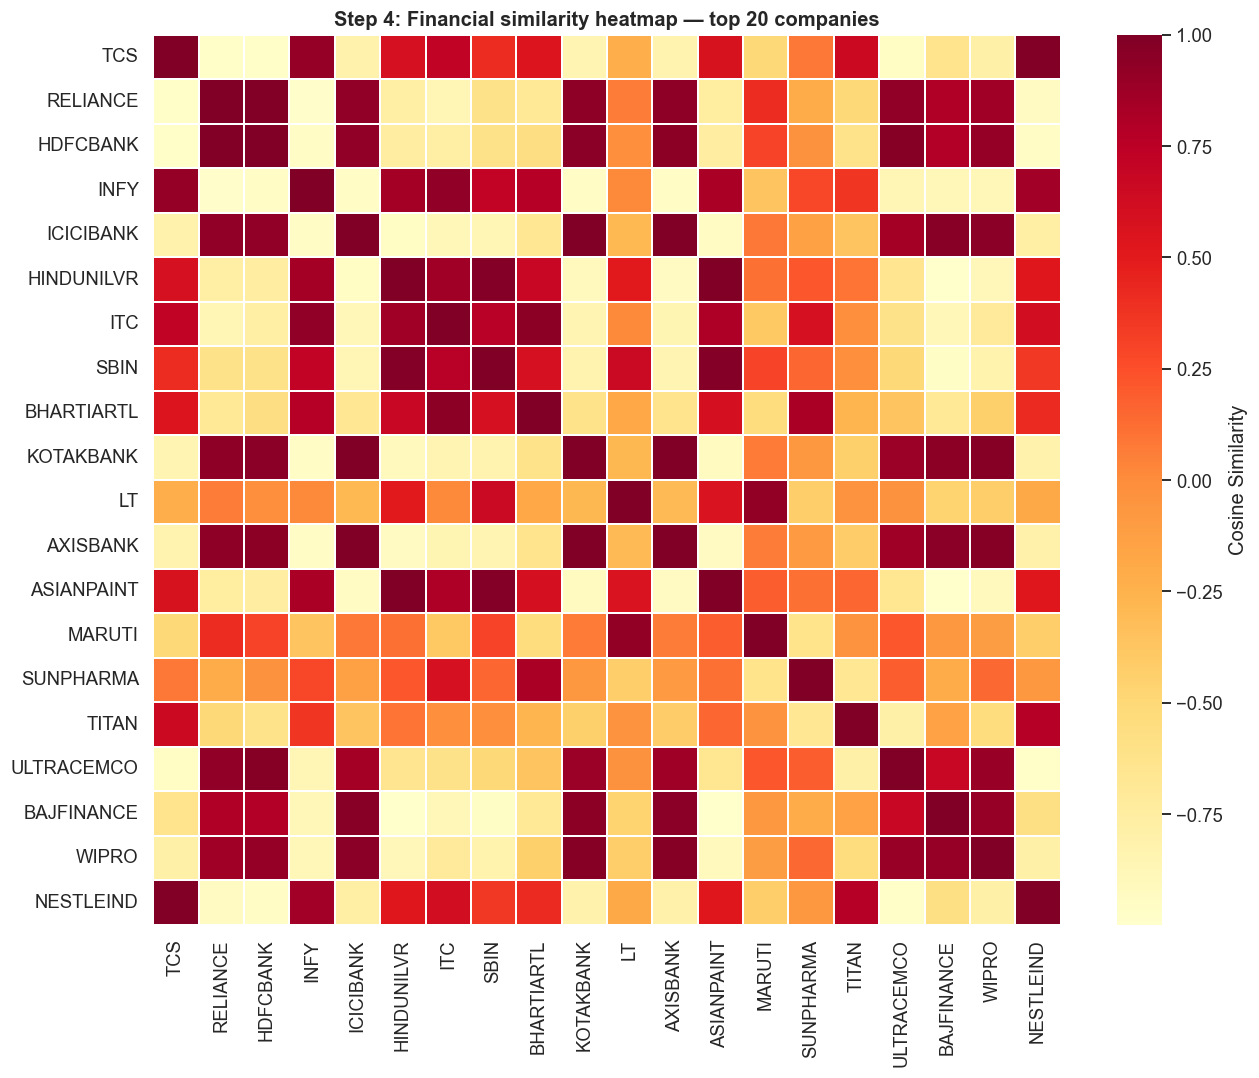

In [38]:
# Step 4 — Similarity heatmap (top 20 companies)
top20 = features['company_name'].head(20).tolist()
sim_top20 = sim_df.loc[top20, top20]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sim_top20, cmap='YlOrRd', annot=False,
            linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Cosine Similarity'})
ax.set_title('Step 4: Financial similarity heatmap — top 20 companies', fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
# Step 5 — Export peer mapping
os.makedirs('../data', exist_ok=True)
peer_df.to_csv('../data/peer_mapping.csv', index=False)
print("✅ Exported to data/peer_mapping.csv")

print("\n" + "="*60)
print("NOTEBOOK 5 SUMMARY — Peer Comparison Engine")
print("="*60)
print(f"Companies mapped : {features.shape[0]}")
print(f"Peers per company: 5")
print(f"Total records    : {len(peer_df)}")
print(f"\nSample peers for Company_1:")
display(peer_df[peer_df['company_name'] == 'Company_1'][
    ['peer_rank', 'peer_name', 'peer_sector', 'similarity_score']
])
print("\n✅ Ready for Notebook 6 — Trend Analysis & Forecasting!")

✅ Exported to data/peer_mapping.csv

NOTEBOOK 5 SUMMARY — Peer Comparison Engine
Companies mapped : 94
Peers per company: 5
Total records    : 470

Sample peers for Company_1:


,peer_rank,peer_name,peer_sector,similarity_score



✅ Ready for Notebook 6 — Trend Analysis & Forecasting!
